In [ ]:
# ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn import tree

# ================================
# 2. Create Training Data
# ================================
train_data = {
    "class": ["First", "Third", "Third", "First", "First", "Third"],
    "sex": ["female", "female", "female", "male", "male", "male"],
    "age": [38.0, 26.0, 18.0, 28.0, 28.0, 21.0]
}

X_train = pd.DataFrame(train_data)

# Let's define target:
# Example: survived = 1 if female, 0 if male
# (Since original problem didn't specify target, we create one)
y_train = (X_train["sex"] == "female").astype(int)

# ================================
# 3. Create Test Data (optional)
# ================================
test_data = {
    "class": ["First", "Third", "First", "First", "Third", "Third"],
    "sex": ["female", "male", "male", "male", "female", "male"],
    "age": [35.0, 35.0, 54.0, 42.0, 3.0, 19.0]
}

X_test = pd.DataFrame(test_data)

Tree: class
prediction: [0 1 0 0 1 1] and prob: [[0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [0.66666667 0.33333333]
 [0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [0.33333333 0.66666667]]
Tree: sex
prediction: [1 0 0 0 1 0] and prob: [[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]
Tree: age
prediction: [0 0 0 0 1 1] and prob: [[0.6 0.4]
 [0.6 0.4]
 [0.6 0.4]
 [0.6 0.4]
 [0.  1. ]
 [0.  1. ]]


c:\Users\parai\anaconda3\envs\nemesis\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
c:\Users\parai\anaconda3\envs\nemesis\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
c:\Users\parai\anaconda3\envs\nemesis\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
c:\Users\parai\anaconda3\envs\nemesis\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
c:\Users\parai\anaconda3\envs\nemesis\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\parai\anaconda3\envs\nemesis\L

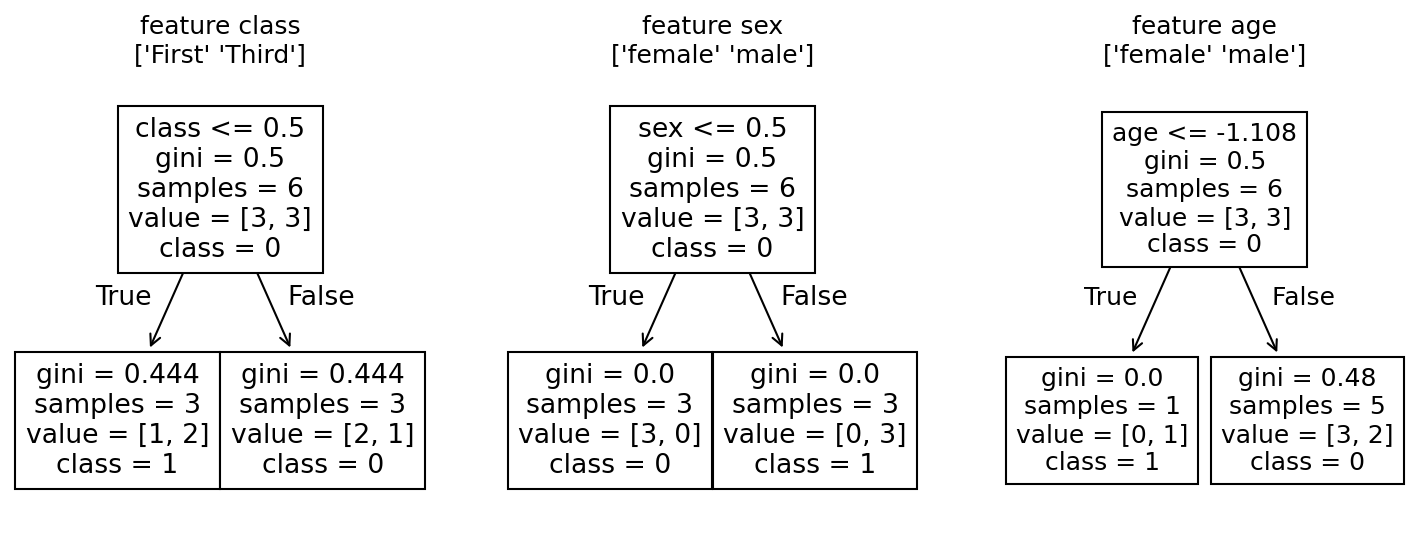

In [51]:
# ================================
# 4. Train 3 depth-1 trees
#    (One feature per tree)
# ================================


# decision tree parameters are correct?
dt = {}

fig, axis = plt.subplots(nrows=1, ncols=3, figsize=(12,4), dpi=150)

for i, f in enumerate(X_train.columns):
    print(f'Tree: {f}')
    
    # Determine if feature is numerical or categorical
    if X_train[f].dtype == "object":
        preprocessor = Pipeline(steps=[
            ('imputer', 'passthrough'), # is 'imputer' supposed to be something here? 
            ('encoder', OneHotEncoder()),
        ])
    else:
        preprocessor = Pipeline(steps=[
            ('imputer', 'passthrough'), # is 'imputer' supposed to be something here? 
            ('scaler', StandardScaler()),
        ])

    # this line onwards is correct
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            criterion='gini',
            max_depth=1,
            random_state=42
        ))
    ])

    # Fit using single feature (from here on, lines are correct)
    dt[f] = pipeline.fit(
        X_train[f].to_numpy().reshape(-1,1),
        y_train
    )
    
    if X_train[f].dtypes=='object':
        str = dt[f]['preprocessor']['encoder'].categories_[0]
        
    tree.plot_tree(dt[f]['classifier'], feature_names=[f], class_names=['0', '1'], ax=axis[i])
    axis[i].set_title(f"feature {f}\n{str}", fontsize=12)

    probs = dt[f].predict_proba(X_test[[f]])
    pred = dt[f].predict(X_test[[f]])
    
    print(f'prediction: {pred} and prob: {probs}')
